In [4]:
#This notebook is for analyzing the LoQS simulations

In [1]:
import numpy as np
import pickle
import itertools
import stim
from collections import Counter
from matplotlib import pyplot as plt
from pygsti.extras import dem_construction as qec_errorprop
from qec_errorprop.construction import dem_tools as dems
from loqs_dems_helpers import * 

ImportError: cannot import name 'PyGSTiPhysicalCircuit' from 'loqs.backends.circuit' (/home/jhhines/LoQS/loqs/backends/circuit/__init__.py)

In [ ]:
from pygsti.extras import sparsedem
from sparsedem.utils import build_masked_hadamard
from scipy.linalg import hadamard

In [3]:
def compute_specified_polarizations_from_dem(dem, masks) -> np.ndarray:
    """
    Compute the outcome distribution from a DEM using log and Hadamard transform.

    Parameters:
        dem: stim.DetectorErrorModel
        masks: np.ndarray

    Returns:
        prob_estimate: np.ndarray
            Array of 2^n probabilities, in increasing binary order
    """
    # Convert DEM to attenuations
    attenuations = np.zeros(len(masks), dtype=float)
    all_bitstrings = np.array([
        [int(bit) for bit in format(n, f"0{dem.num_detectors}b")]
        for n in masks])

    for event in dem:
        prob = event.args_copy()[0]
        targets = [target.val for target in event.targets_copy()]
        event_vec = [1 if (dem.num_detectors - idx - 1) in targets else 0 for idx in range(dem.num_detectors)]
        attenuation = -np.log(1 - 2 * prob)
        attenuations += attenuation * (1 - (-1) ** np.dot(all_bitstrings, event_vec)) / 2

    # Compute polarizations from attenuations
    polarizations = np.exp(-attenuations)

    # Compute probabilities from polarizations
    return polarizations

In [4]:
def compute_all_polarizations(syndrome_counts):
    n = len(next(iter(syndrome_counts)))  # number of bits in syndrome
    n_runs = sum(syndrome_counts.values())
    size = 2 ** n
    
    # Create vector of observed bitstring probabilities
    probabilities = np.zeros(size)
    for i in range(size):
        bitstring = format(i, f"0{n}b")
        probabilities[i] = syndrome_counts.get(bitstring, 0) / n_runs
    
    # Convert to polarizations
    d_pol_d_prob = hadamard(size)
    cov_input = np.diag(probabilities) - np.outer(probabilities, probabilities)
    cov_input /= n_runs

    J = d_pol_d_prob
    covariance_matrix = J @ cov_input @ J.T
    
    polarizations = hadamard(size) @ probabilities

    return polarizations, covariance_matrix

In [5]:
def to_int(bs): return int(bs, 2)    

In [6]:
def compute_percentile(llrs, computed_test_statistic):
    """
    Compute the approximate percentile of computed_test_statistic in the distribution defined by llrs.

    Parameters:
    llrs_2 (list of floats): Samples defining distribution.
    computed_test_statistic (float): The test statistic to find the percentile for.

    Returns:
    float: The approximate percentile of computed_test_statistic in llrs.
    """
    # Sort the distribution
    sorted_llrs = sorted(llrs)
    
    # Count how many values are less than or equal to the computed_test_statistic
    count_less_equal = sum(1 for x in sorted_llrs if x <= computed_test_statistic)
    
    # Calculate the percentile
    percentile = (count_less_equal / len(sorted_llrs)) * 100
    
    return percentile

In [7]:
def loglikelihood(probs, samples):
    return float(np.sum([x * np.log(probs[bs]) for bs, x in samples.items()])) #uses probability distribution computed via DEM

def alternate_hypothesis_loglikelihood(samples):
    total_counts = sum(list(samples.values()))
    return float(np.sum([x * np.log(x / total_counts) for x in samples.values()]))

def llr(probs, samples):
    return - 2 * (loglikelihood(probs, samples) - alternate_hypothesis_loglikelihood(samples))

In [8]:
def compute_random_polarizations(counts, num_polarizations):
    '''
    computes random set of polarizations and their covariance from a dictionary of detector counts
    '''
    #construct prob vector
    n_runs = sum(counts.values())
    syn_counts = np.fromiter(counts.values(), dtype=float)
    probabilities = syn_counts/n_runs
    #pick polarizations
    n_bits = len(next(iter(counts)))
    pol_masks = np.random.choice(2**n_bits, size=num_polarizations, replace=False)
    syndrome_masks = [int(synd, 2) for synd in counts.keys()]
    #get appropriate Hadamard submatrix and compute
    H_sub = build_masked_hadamard(pol_masks, syndrome_masks)
    polarizations = H_sub @ syn_counts / n_runs

    #repeat this procedure with the uncertainties
    d_pol_d_prob = H_sub
    cov_input = np.diag(probabilities) - np.outer(probabilities, probabilities)
    cov_input /= n_runs

    J = d_pol_d_prob
    covariance_matrix = J @ cov_input @ J.T
    
    return pol_masks, polarizations, covariance_matrix

In [9]:
# a bootstrapped significance threshold
def compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000):
    llrs = []
    for i in range(num_bootstraps):
        outcomes, logicals, _ = sampler.sample(shots=total_counts)
        bs_samples = dict(Counter([(''.join(['1' if b else '0' for b in row])) for row in outcomes]))
        # This is a bit silly but it's how I wrote the code higher up
        bs_probs = {bs:probs_list[to_int(bs[::-1])] for bs in bs_samples.keys()}
        llrs.append(llr(bs_probs, bs_samples))
    
    significance_threshold_1_bs = np.mean(llrs) + 2 * np.std(llrs)
    computed_test_statistic = llr(probs, samples_loqs)
    percentile = compute_percentile(llrs, computed_test_statistic)

    return percentile

In [10]:
def compute_bootstrapped_significance_hamming(dem, samples_loqs, total_counts, num_bootstraps=1000):
    probs_by_weight = {h:0. for h in range(0, bslen + 1)}
    samples_by_weight =  {h:0 for h in range(0, bslen + 1)}
    all_bitstrings = [''.join(p) for p in itertools.product('01', repeat=bslen)]
    
    for i, bs in enumerate(all_bitstrings):
        probs_by_weight[bs.count('1')] += probs_list[i]
        samples_by_weight[bs.count('1')] += samples_loqs.get(bs, 0)
        
    samples_by_weight = {x:y for x,y in samples_by_weight.items() if y > 0}

    computed_test_statistic = llr(probs_by_weight, samples_by_weight)

    llrs_2 = []
    for i in range(num_bootstraps):
        outcomes, logicals, _ = sampler.sample(shots=total_counts)
        samples = dict(Counter([''.join(['1' if b else '0' for b in row]) for row in outcomes]))
        
        samples_by_weight =  {h:0 for h in range(0, bslen + 1)}
        for i, bs in enumerate(all_bitstrings):
            samples_by_weight[bs.count('1')] += samples.get(bs, 0)
        samples_by_weight = {x:y for x,y in samples_by_weight.items() if y > 0}
    
        llrs_2.append(llr(probs_by_weight, samples_by_weight))
    
    significance_threshold_2_bs = np.mean(llrs_2) + 2 * np.std(llrs_2)
    percentile = compute_percentile(llrs_2, computed_test_statistic)

    return percentile

In [11]:
with open('loqs_data/loqs_dems2_standard_depol.pkl', 'rb') as f:
    baseline_result = pickle.load(f)
f.close()    
baseline_events = [i for i in baseline_result['dem']]

In [12]:
from itertools import combinations_with_replacement

def distinct_bitwise_xor(strings, k):
    distinct_xors = set()  # Use a set to store distinct XOR results

    # Iterate over all combinations of strings with lengths from 1 to k
    for r in range(1, k + 1):
        for combo in combinations_with_replacement(strings, r):
            # Calculate the bitwise XOR for the current combination
            xor_result = int(combo[0], 2)  # Start with the first string
            for s in combo[1:]:
                xor_result ^= int(s, 2)  # Perform XOR with the next string
            
            # Convert the result back to a binary string and strip the '0b' prefix
            xor_string = bin(xor_result)[2:]
            # Pad with leading zeros to match the length of the original strings
            xor_string = xor_string.zfill(len(strings[0]))
            distinct_xors.add(xor_string)  # Add to the set of distinct results

    return list(distinct_xors)  # Convert the set back to a list

In [33]:
def compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000):
    probs_coarse = {'other':0}
    samples_coarse =  {'other':0}
    all_bitstrings = [''.join(p) for p in itertools.product('01', repeat=bslen)]
    
    for i, bs in enumerate(all_bitstrings): #probabilities are for the reversed string
        if bs[::-1] in baseline_events:
            probs_coarse[bs[::-1]] = probs_list[i]
            samples_coarse[bs[::-1]] = samples_loqs.get(bs[::-1], 0)
        else:
            probs_coarse['other'] += probs_list[i]
            samples_coarse['other'] += samples_loqs.get(bs[::-1], 0)

    samples_coarse = {x:y for x,y in samples_coarse.items() if y > 0}
    computed_test_statistic = llr(probs_coarse, samples_coarse)

    llrs = []
    for i in range(num_bootstraps):
        outcomes, logicals, _ = sampler.sample(shots=total_counts)
        samples = dict(Counter([''.join(['1' if b else '0' for b in row]) for row in outcomes]))
        
        samples_coarse =  {'other':0}
        
        for i, bs in enumerate(all_bitstrings):
            if bs in baseline_events:
                samples_coarse[bs] = samples.get(bs, 0)
            else:
                samples_coarse['other'] += samples.get(bs, 0)
    
        samples_coarse = {x:y for x,y in samples_coarse.items() if y > 0}
    
        llrs.append(llr(probs_coarse, samples_coarse))
    
    significance_threshold_2_bs = np.mean(llrs) + 2 * np.std(llrs)

    percentile = compute_percentile(llrs, computed_test_statistic)

    return percentile

In [137]:
upto_two_events = distinct_bitwise_xor(baseline_events,2)
def compute_epsilons(est_pols, data_pols, stds, upto=2):
    if upto==2:
        upto_two_masks = [int(k,2) for k in upto_two_events if int(k,2)>0]
    else:
        upto_two_masks = [int(k,2) for k in baseline_events if int(k,2)>0]
    test_dem_pols = [est_pols[k] for k in upto_two_masks]
    test_data_pols = [data_pols[k] for k in upto_two_masks]
    test_data_std = [stds[k] for k in upto_two_masks]
    epsilons = (np.array(test_dem_pols)-np.array(test_data_pols))/np.array(test_data_std)
    return epsilons, (np.array(test_dem_pols)-np.array(test_data_pols))

In [34]:
rounds = 2
ranks = range(1) 
js = range(50)#range(100)
#scha low shots ranks = range(10) js = range(20)
bslen = 13

percentiles_probs = []
percentiles_hamming = []
percentiles_high = []
pols_data = []
pols_estimated = []
stds = []

for j in js:
    for rank in ranks:
        with open(f'loqs_data/loqs_dems_sh_{rounds}_{rank}_{j}_test.pkl', 'rb') as f:
            data = pickle.load(f)
        f.close()
        #{'dem_outcome_dist':outcome_distribution, 'dem':dem, 'loqs_samples': count_dict, 'edict':error_rates_dict}
    
        probs_list = data['dem_outcome_dist']
        dem_dict = data['dem']
        stim_dem_str = dems.format_dem_stim(dem_dict, n_logical=0)
        dem = stim.DetectorErrorModel(stim_dem_str)
        sampler = dem.compile_sampler()
    
        samples_loqs = data['loqs_samples']
        total_counts = sum(list(samples_loqs.values()))
        probs = {bs:probs_list[to_int(bs[::-1])] for bs in samples_loqs.keys()}

        all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}
        
        p1 = compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000)
        p2 = compute_bootstrapped_significance_hamming(sampler, samples_loqs, total_counts, num_bootstraps=1000)
        p3 = compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000)
    
        percentiles_probs.append(p1)
        percentiles_hamming.append(p2)
        percentiles_high.append(p3)

        all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}


        pols, cov = compute_all_polarizations(samples_loqs)

        

        pols_data.append(pols)#compute_all_polarizations(samples_loqs))
        stds.append([np.sqrt(cov[i][i]) for i in range(len(pols))])
        pols_estimated.append(compute_all_polarizations(all_probs))

KeyboardInterrupt: 

In [102]:
with open(f'sh_bootstrap_significance_results_{rounds}.pkl', 'rb') as f:
    bootstrap_results = pickle.load(f)
f.close()

In [107]:
np.where(np.array(bootstrap_results['all'])>95)

(array([47]),)

In [110]:
np.where(np.array(bootstrap_results['main'])>95)

(array([ 9, 21]),)

In [115]:
with open(f'sh_pol_results_{rounds}.pkl', 'rb') as f:
    pols_data, stds, pols_estimated = pickle.load(f)
f.close()

In [116]:
#these are very clean
for i in range(50):
    eps = compute_epsilons(pols_estimated[i][0], pols_data[i], np.array(stds[i]), upto=2)
    print(np.mean(np.abs(eps)))
    if np.mean(np.abs(eps))>2:
        print(i, eps[np.where(np.abs(eps)>3)], np.where(np.abs(eps)>100))

0.3222103790183886
0.31498231519863273
0.36511808301201787
0.3671370395477224
0.30609030585149943
0.31843250402888484
0.2776648206003526
0.5334100302245399
0.5004031826824238
0.33723193954872316
0.8978949183830107
0.29493987751778644
0.34302613714750535
0.29121083989617097
0.44060997271045005
0.42069788338765
0.4226381304988993
0.347583240825305
0.9418446428013005
0.34094718830746445
0.5049791761478242
0.7014818164602791
0.3905631854663839
0.2580127586738819
0.36556746995735995
0.9536182544816028
0.28027344913385066
0.31815408991533994
0.31207266559027447
0.26581738422409473
0.3518593025819684
0.4509778394790368
0.25649465822330314
0.36866774181261314
0.30606976975063677
0.32017244340826095
0.6754516444210905
0.26454384856026475
0.5931457099684917
0.4298145834912112
0.3136179933706924
0.5417403082030802
0.31437023766502037
0.4127145644856215
0.7676390331690881
1.1028417309595524
0.40744233992264306
0.36321724304780106
0.5278064237904678
0.2629940753866381


<ErrorbarContainer object of 3 artists>

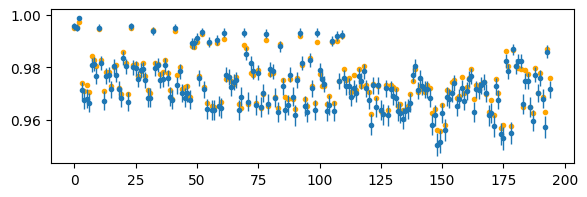

In [119]:
plt.figure(figsize=(3.375*2, 2))
masks = [int(k,2) for k in baseline_events if int(k,2)>0]
test_dem_pols = [pols_estimated[i][0][k] for k in masks]
test_data_pols = [pols_data[i][k] for k in masks]
test_data_std = [stds[i][k] for k in masks]
plt.scatter(range(len(test_dem_pols)), test_dem_pols, marker='.', color='orange')
plt.errorbar(range(len(test_data_pols)),test_data_pols, yerr=np.array(test_data_std), linewidth=0, marker='.', elinewidth=1)

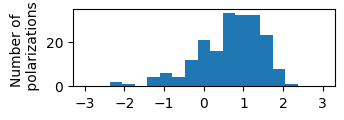

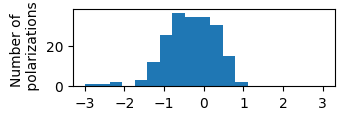

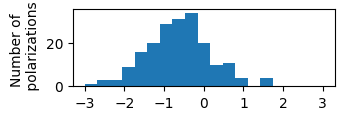

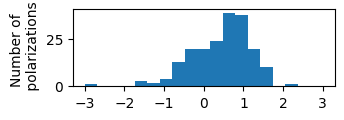

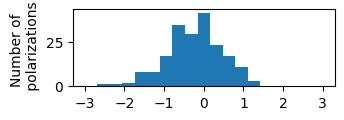

In [120]:
bins = np.linspace(-3,3,num=20)
for i in range(5):
    eps = compute_epsilons(pols_estimated[i][0], pols_data[i], np.array(stds[i]), upto=1)
    plt.figure(figsize=(3.375, 1))
    plt.hist(eps[0], bins=bins)
    #plt.ylim(0,1100)
    plt.xticks([-3,-2,-1,0,1,2,3])
    #plt.yticks([0,500,1000])
    plt.ylabel('Number of \n polarizations')

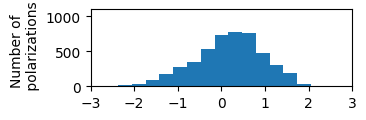

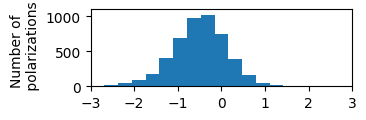

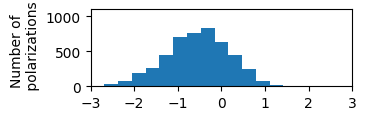

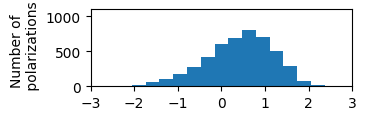

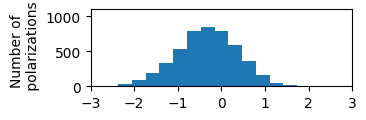

In [121]:
bins = np.linspace(-3,3,num=20)
for i in range(5):
    eps = compute_epsilons(pols_estimated[i][0], pols_data[i], np.array(stds[i]), upto=2)
    plt.figure(figsize=(3.375, 1))
    plt.hist(eps[0], bins=bins)
    plt.ylim(0,1100)
    plt.xlim(-3,3)
    plt.xticks([-3,-2,-1,0,1,2,3])
    plt.yticks([0,500,1000])
    plt.ylabel('Number of \n polarizations')

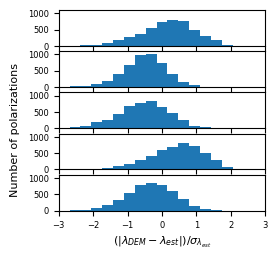

In [128]:
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(3, 3), sharex=True)

for i in range(5):
    eps = compute_epsilons(pols_estimated[i][0], pols_data[i], np.array(stds[i]), upto=2)
    axs[i].hist(eps[0], bins=bins)
    axs[i].set_ylim(0, 1100)
    axs[i].set_yticks([0, 500, 1000])
    axs[i].tick_params(axis='y', labelsize=6)

# Set shared x-axis limits and ticks
axs[4].set_xlim(-3, 3)  # Set x limits for the last subplot
axs[4].set_xticks([-3, -2, -1, 0, 1, 2, 3])  # Set x ticks for the last subplot
axs[4].tick_params(axis='x', labelsize=6)
axs[4].set_xlabel(r'''$(|\lambda_{DEM}-\lambda_{est}|)/\sigma_{\lambda_{est}}$''', fontsize=8)

# Set the y-axis label for all subplots
fig.text(0.04, 0.5, 'Number of polarizations', va='center', rotation='vertical', fontsize=8)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])  # Adjust the layout
plt.subplots_adjust(hspace=0.15)

# Show the combined figure
plt.savefig('plots/random_sh_specified_polarizations_examples.pdf')

In [ ]:
bootstrap_results = {'all':percentiles_probs, 'hamming':percentiles_hamming, 'main': percentiles_high}

In [27]:
# with open(f'shca_bootstrap_significance_results_{rounds}.pkl', 'wb+') as f:
#     pickle.dump(bootstrap_results, f)
# f.close()

In [132]:
rounds = 2
#ranks = range(1) 
#js = range(10)#range(100)
#scha low shots 
ranks = range(1) #range(10) 
js = range(50)#range(20)
bslen = 13

percentiles_probs = []
percentiles_hamming = []
percentiles_high = []
pols_data = []
pols_estimated = []
stds = []

for j in js:
    print(j)
    for rank in ranks:
        with open(f'loqs_data/loqs_dems_shca_{rounds}_{rank}_{j}_test.pkl', 'rb') as f: #_low_shots
            data = pickle.load(f)
        f.close()
        #{'dem_outcome_dist':outcome_distribution, 'dem':dem, 'loqs_samples': count_dict, 'edict':error_rates_dict}
    
        probs_list = data['dem_outcome_dist']
        dem_dict = data['dem']
        stim_dem_str = dems.format_dem_stim(dem_dict, n_logical=0)
        dem = stim.DetectorErrorModel(stim_dem_str)
        sampler = dem.compile_sampler()
    
        samples_loqs = data['loqs_samples']
        total_counts = sum(list(samples_loqs.values()))
        probs = {bs:probs_list[to_int(bs[::-1])] for bs in samples_loqs.keys()}

        all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}
        
        p1 = compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000)
        p2 = compute_bootstrapped_significance_hamming(sampler, samples_loqs, total_counts, num_bootstraps=1000)
        p3 = compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000)
    
        percentiles_probs.append(p1)
        percentiles_hamming.append(p2)
        percentiles_high.append(p3)

        pols, cov = compute_all_polarizations(samples_loqs)

        

        pols_data.append(pols)#compute_all_polarizations(samples_loqs))
        stds.append([np.sqrt(cov[i][i]) for i in range(len(pols))])
        pols_estimated.append(compute_all_polarizations(all_probs))
        
        print(j, p1, p2, p3, np.sum(np.array(pols_data[j])-np.array(pols_estimated[j][0]))/len(pols_data[j]))

0


/tmp/ipykernel_6354/2852073204.py:49: RuntimeWarning: invalid value encountered in sqrt
  stds.append([np.sqrt(cov[i][i]) for i in range(len(pols))])


0 1.5 58.599999999999994 11.4 0.007049116179748904
1
1 42.1 51.800000000000004 49.8 -0.00202429564864981
2
2 5.800000000000001 14.499999999999998 9.700000000000001 0.0023421404167243143
3
3 52.6 20.9 34.8 0.0017495086085154155
4
4 57.49999999999999 46.1 51.9 -0.0014112176255889342
5
5 27.1 11.799999999999999 17.0 0.00024385845130436848
6
6 63.1 93.7 77.0 -0.0030921642226675594
7
7 63.0 28.799999999999997 39.7 0.004126969266618596
8
8 45.0 56.8 70.7 0.006422772664941623
9
9 52.900000000000006 24.5 85.7 -0.0028255366578959773
10
10 1.4000000000000001 16.2 5.800000000000001 0.00390608350244237
11
11 13.5 57.3 83.89999999999999 0.00030069534889587407
12
12 9.5 31.1 27.900000000000002 0.004970674932266772
13
13 19.2 36.8 9.5 -0.0024176534379477532
14
14 9.0 26.400000000000002 39.1 0.002562968465910531
15
15 68.8 17.599999999999998 87.9 0.000633601563395314
16
16 84.1 83.7 99.4 -0.0036820013199518886
17
17 44.0 70.5 16.900000000000002 0.0025467710851904135
18
18 61.7 80.5 21.7 0.006832190387

In [14]:
with open(f'shca_pol_results_2_5000.pkl', 'rb') as f:
    pols_data, stds, pols_estimated, percentiles_probs, percentiles_high = pickle.load(f)
f.close()

In [17]:
np.where(np.array(percentiles_probs)>95)

(array([27, 31]),)

In [19]:
np.where(np.array(percentiles_high)>95)

(array([16, 20, 25]),)

In [142]:
test_dem_pols = [pols_estimated[-1][0][k] for k in upto_two_masks]#compute_specified_polarizations_from_dem(dem, [int(k[::-1],2) for k in upto_two_events])

NameError: name 'upto_two_masks' is not defined

In [135]:
test_data_pols = [pols_data[-1][k] for k in upto_two_masks]

NameError: name 'upto_two_masks' is not defined

In [311]:
test_data_std = [np.sqrt(cov[k][k]) for k in upto_two_masks]

/tmp/ipykernel_345018/3403436360.py:1: RuntimeWarning: invalid value encountered in sqrt
  test_data_std = [np.sqrt(cov[k][k]) for k in upto_two_masks]


In [312]:
np.mean(np.array(test_dem_pols)-np.array(test_data_pols))

np.float64(0.0027783935850461488)

In [302]:
epsilons = (np.array(test_dem_pols)-np.array(test_data_pols))/np.array(test_data_std)

In [306]:
epsilons

array([ 0.49640515, -0.36084073,  0.42821048, ...,  1.00505898,
        1.04314529, -1.19250849], shape=(4766,))

In [307]:
len(np.where(np.abs(epsilons)>1)[0])/len(epsilons)

0.20751154007553504

In [308]:
len(np.where(np.abs(epsilons)>2)[0])/len(epsilons)

0.007343684431389006

nan


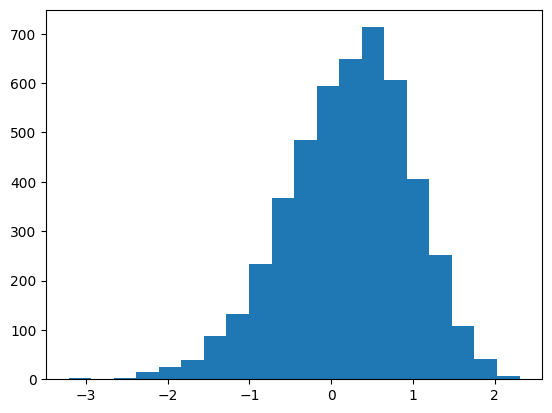

In [299]:
#plt.axvline(np.median((np.array(test_dem_pols)-np.array(test_data_pols))/np.array(test_data_std)), color='black')
plt.hist((np.array(test_dem_pols)-np.array(test_data_pols))/np.array(test_data_std),bins=20)
print(np.median((np.array(test_dem_pols)-np.array(test_data_pols))/np.array(test_data_std)))

1.687639900986447 0.007064404814639709


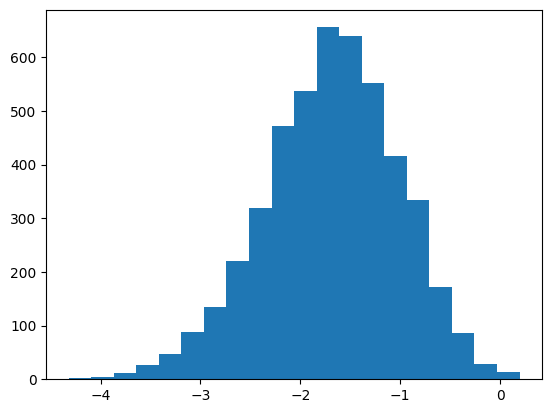

0.6091511732278256 0.0030078507970655874


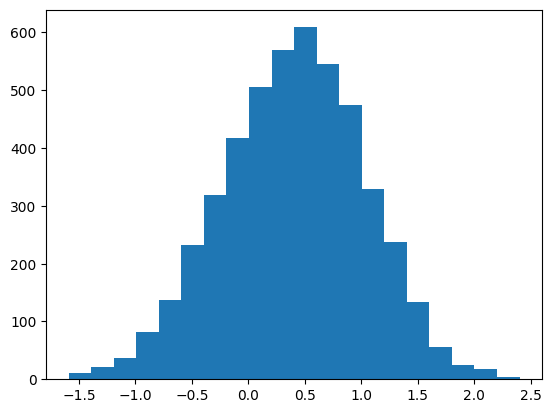

0.7663259038232119 0.003043367667307482


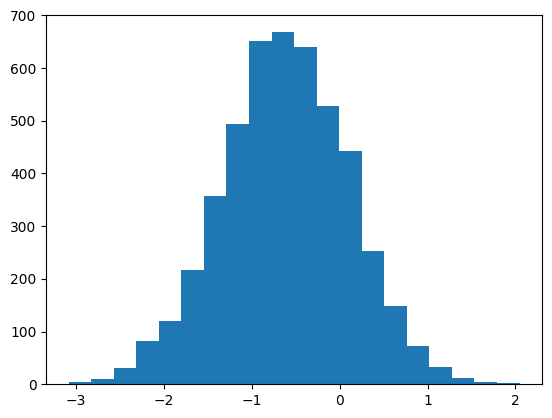

0.5884202022731655 0.0028372367893278305


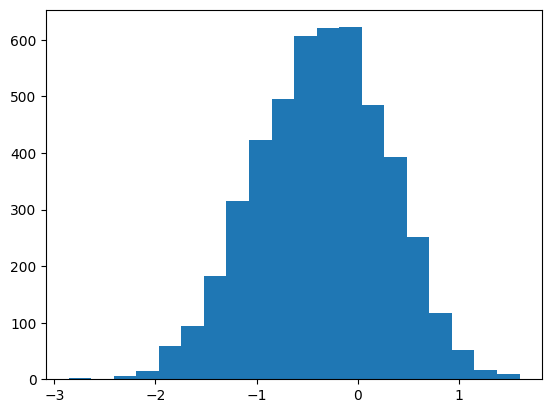

0.6415467507486736 0.0031246675707513943


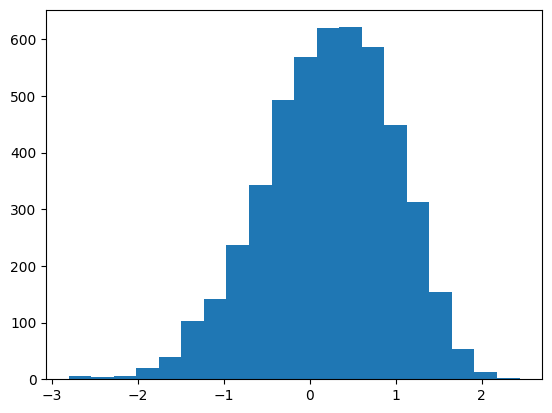

0.5311967386735101 0.002669231213333072


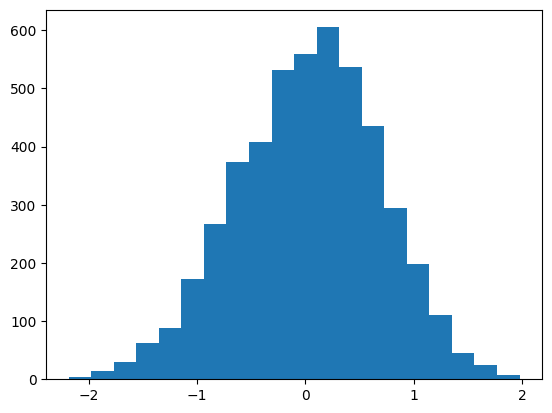

0.8175855350427621 0.004142844889481076


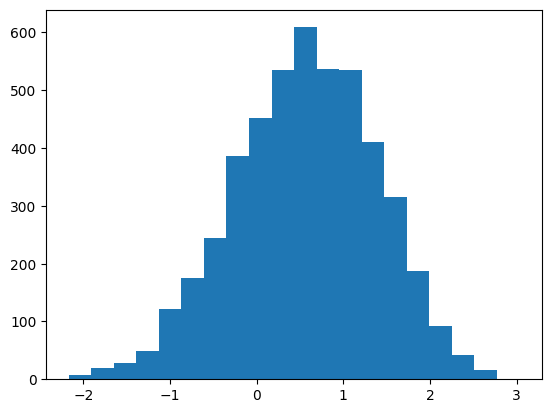

0.9074408026954929 0.004370140242518404


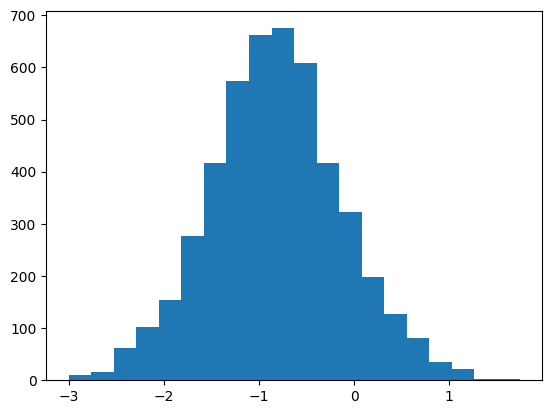

1.4304524325825236 0.006289275541175543


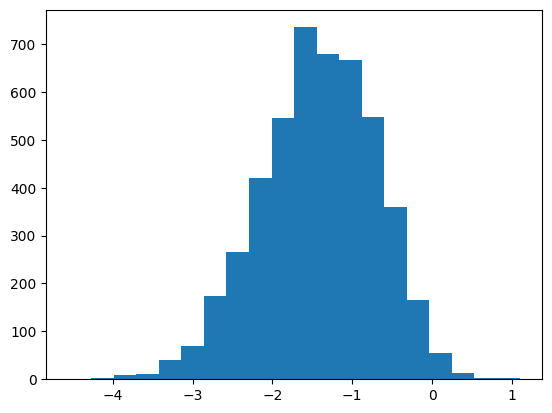

0.8218630415721984 0.0037001020431716674


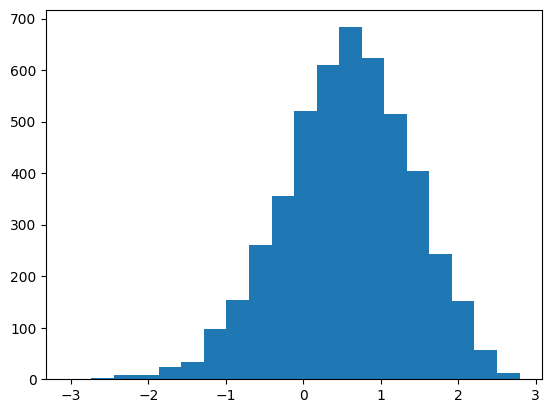

0.9444471067074139 0.003849861986108472


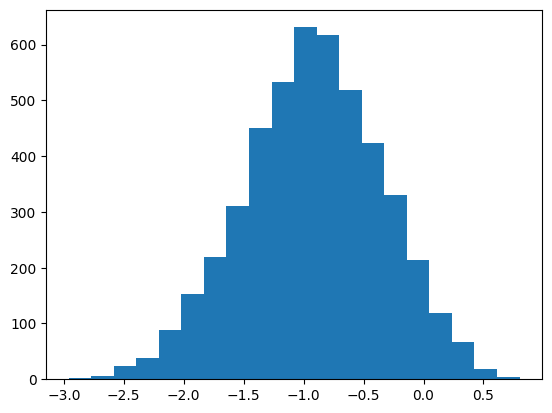

0.572688476467017 0.0024503611756983186


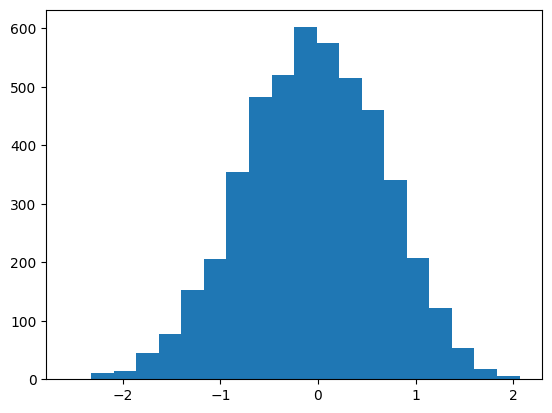

1.1053510102378612 0.005395574179637957


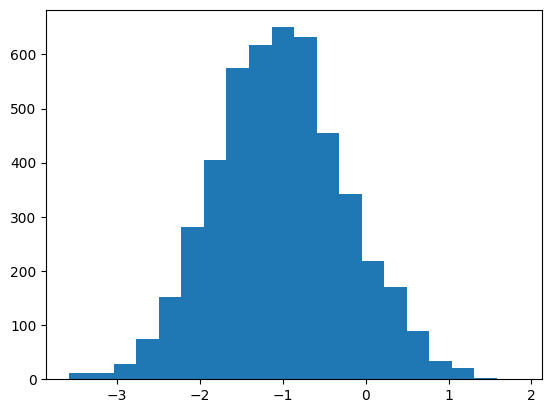

0.6209747745305657 0.0031030658068653067


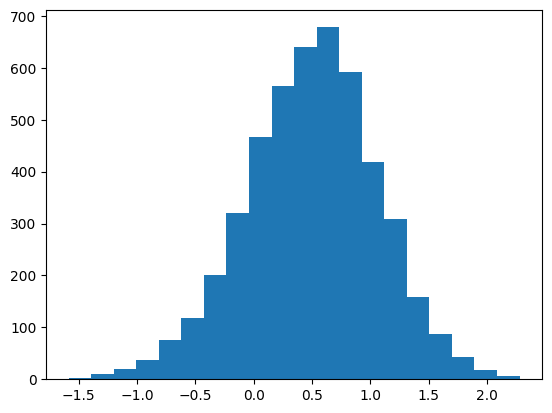

0.7596964858377703 0.0033901372225362283


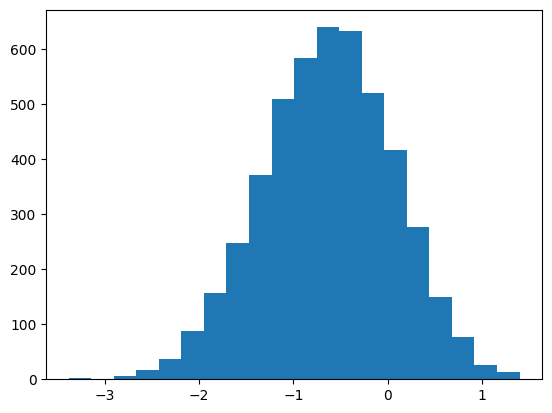

0.6754306304647513 0.0031133047412230472


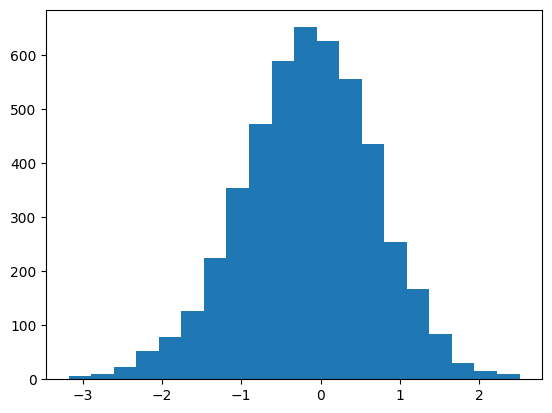

0.9523464624124571 0.0047793220638444114


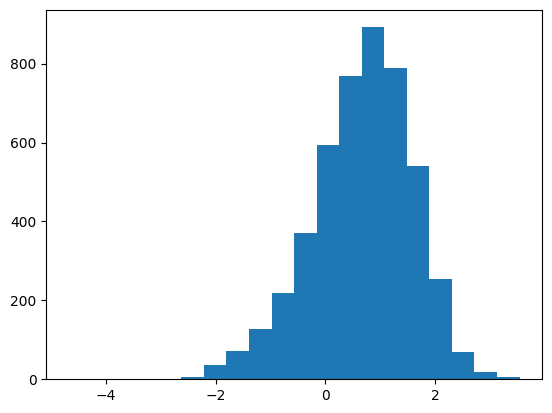

0.7713613309517419 0.0037324127533981447


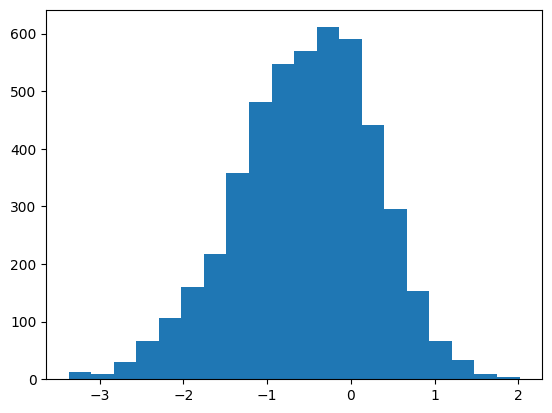

1.500170152135118 0.006961912044033925


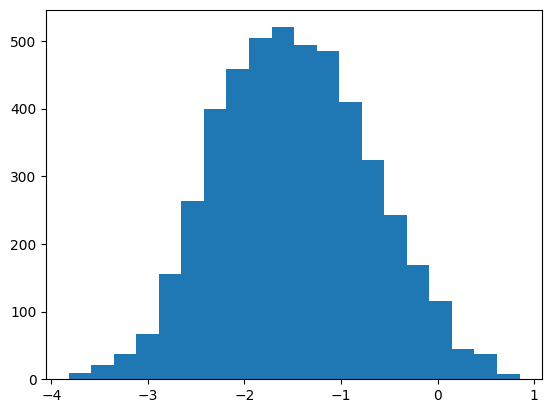

1.0137692507642604 0.004541385318832781


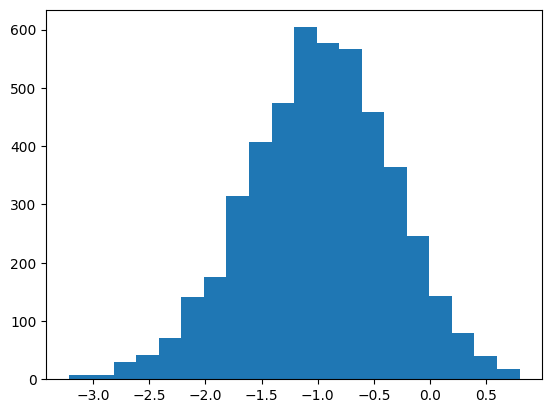

0.590825827930978 0.0024816336494834375


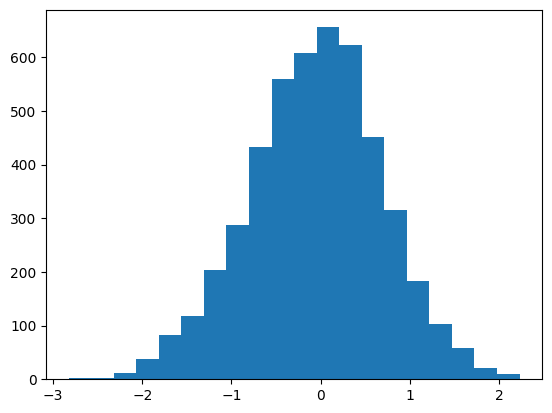

0.6295149830116896 0.0026163619388830366


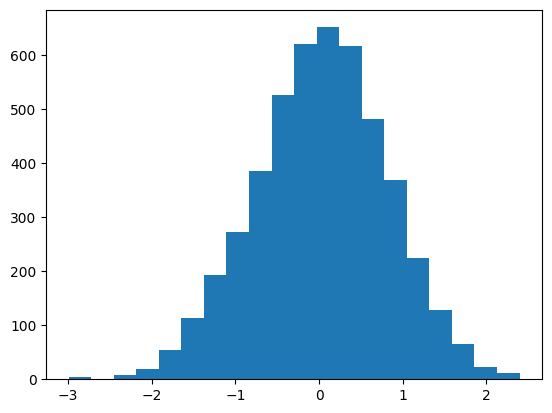

0.6455441116740971 0.0028080745074762284


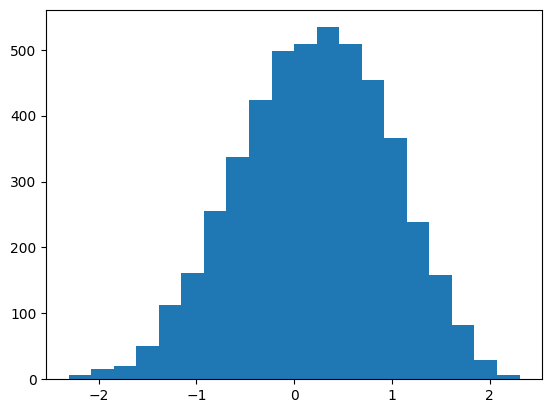

0.7068418256037714 0.003469331219580962


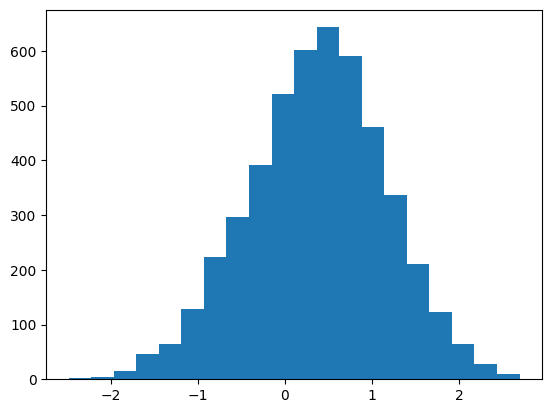

0.5675989295247353 0.002360828224643175


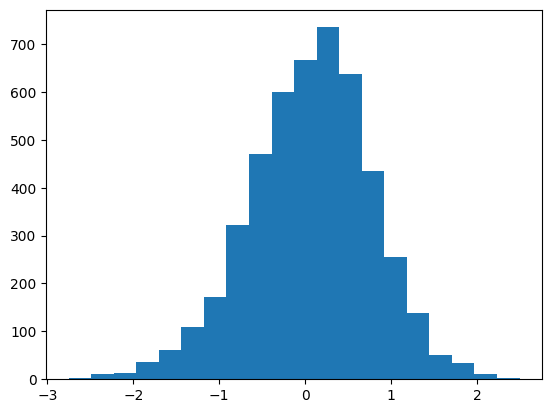

1.231085720846893 0.006359836271741245


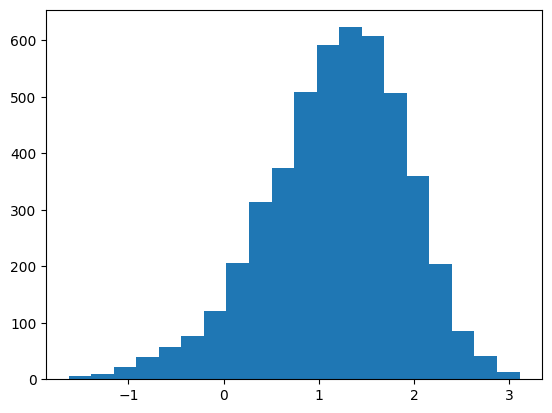

1.3552005984939848 0.007270187058863989


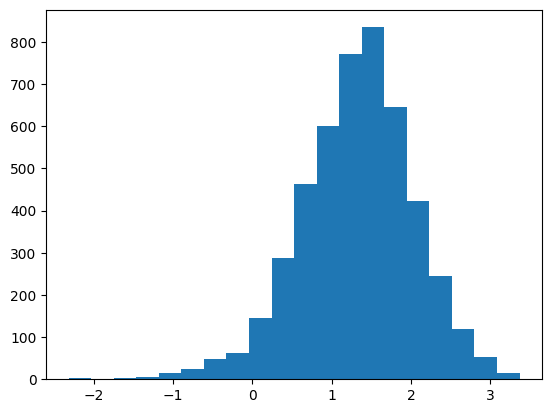

0.7153334609975461 0.003550216497495706


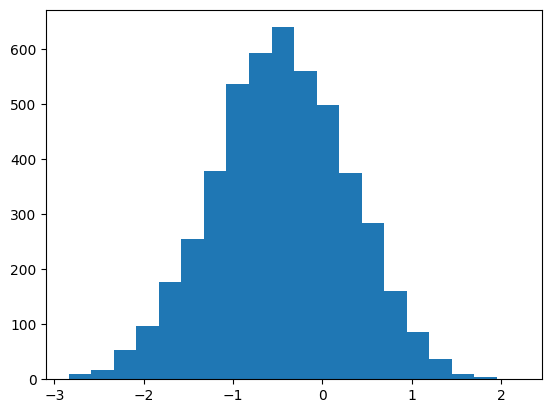

1.0064249650472756 0.0044111061885050585


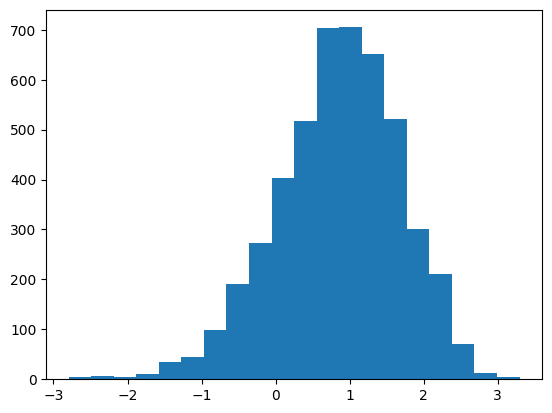

0.6110969807004321 0.002878340612511876


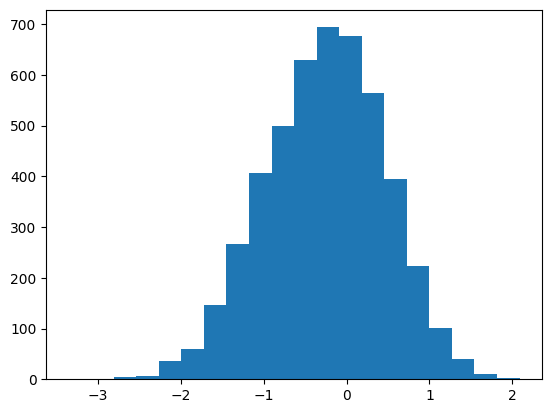

0.9337489125821 0.0041972416022197185


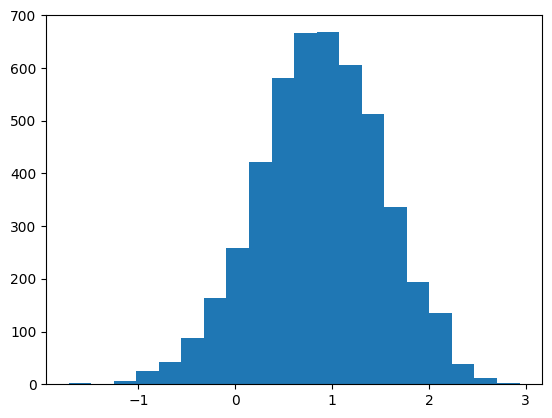

0.6283102109275203 0.002871616009999594


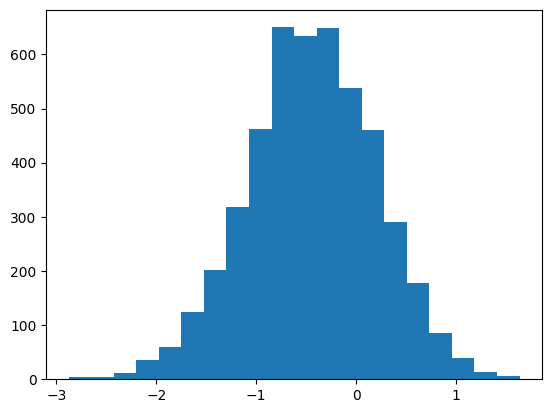

0.9843512577432546 0.004843878554416222


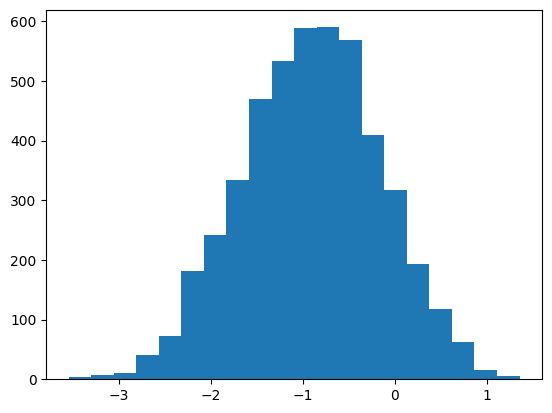

0.6810678160233103 0.0030527956265592356


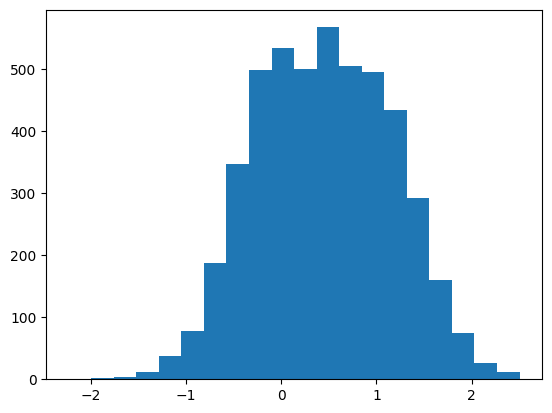

0.6312854850111757 0.0029390514650153065


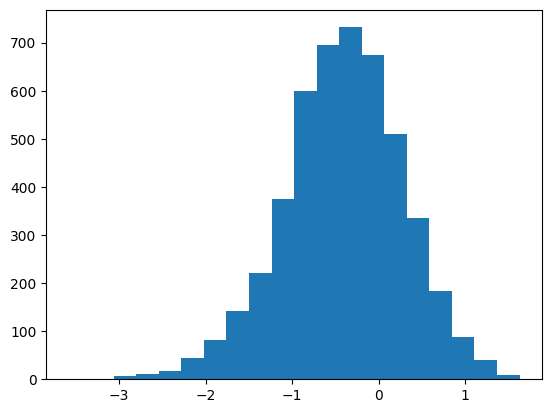

0.5225888467325047 0.002433415587328846


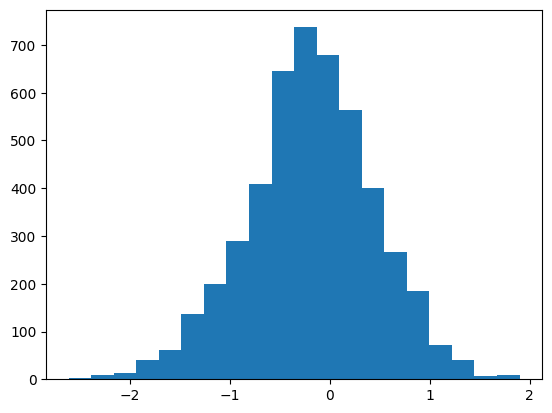

1.4221143535084093 0.006636201684700256


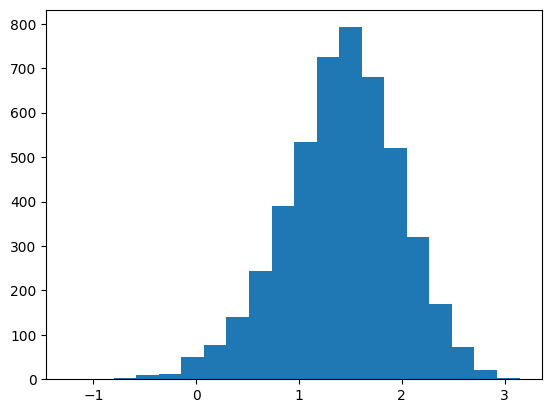

0.6559229680426084 0.0028352640929219853


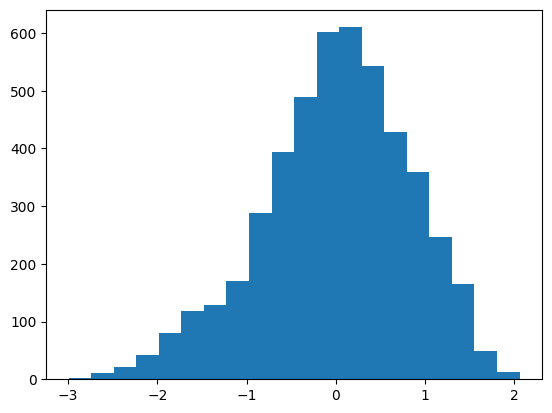

0.6128158651971475 0.002553609263451032


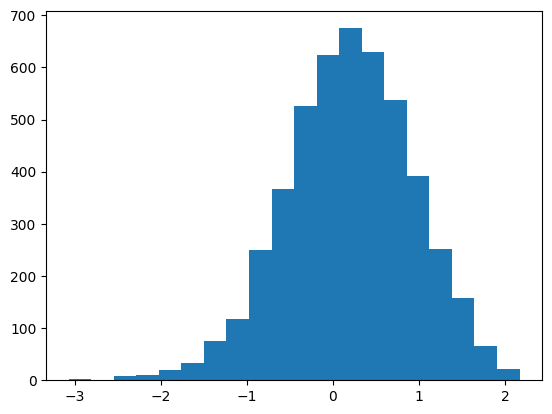

0.7579665855285018 0.0033171877080359342


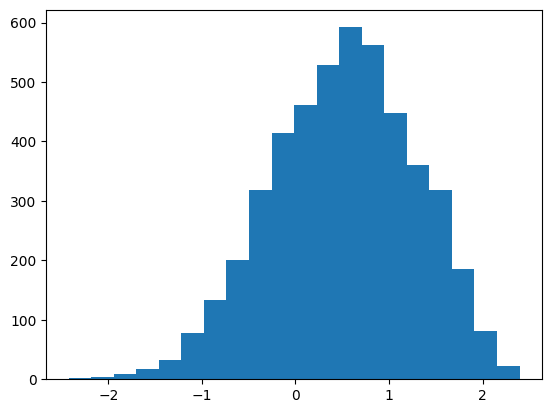

0.7166214635064931 0.0029532907518045473


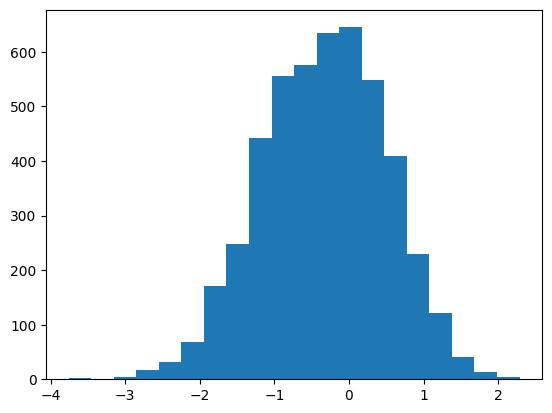

0.6491467278039914 0.0032059484506654617


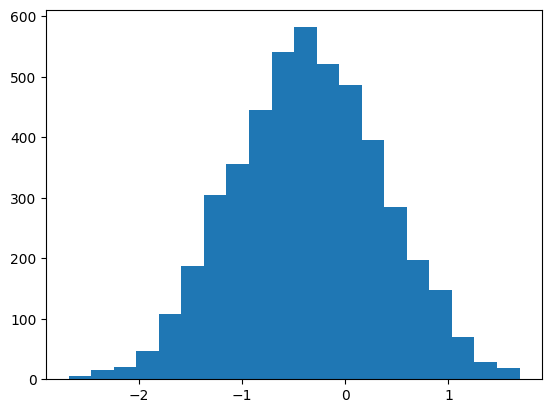

0.9053007666173697 0.0037670916352049158


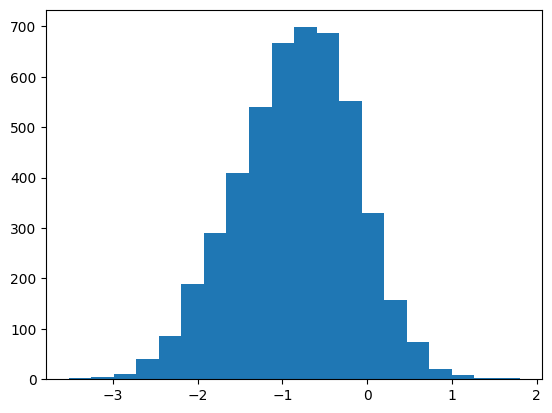

0.5292769040430771 0.002209450189129191


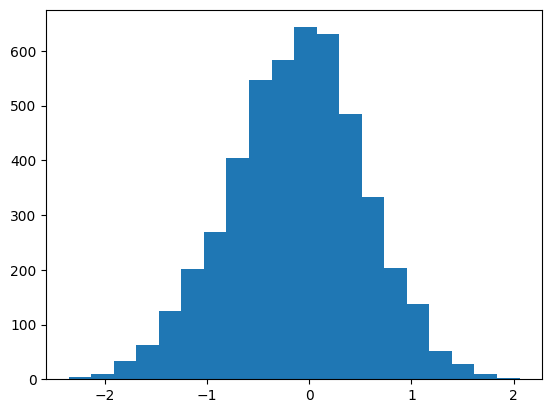

0.6832585703096957 0.002755981282013299


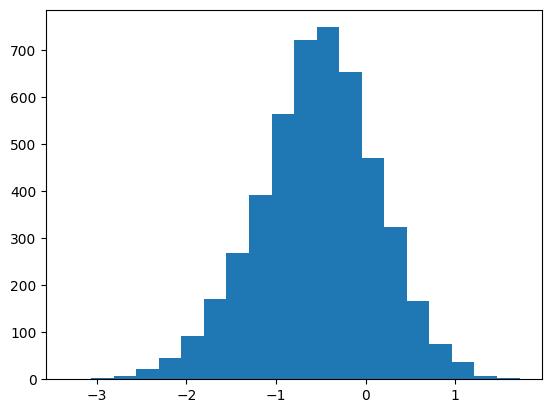

1.0238111787159694 0.004580538919743398


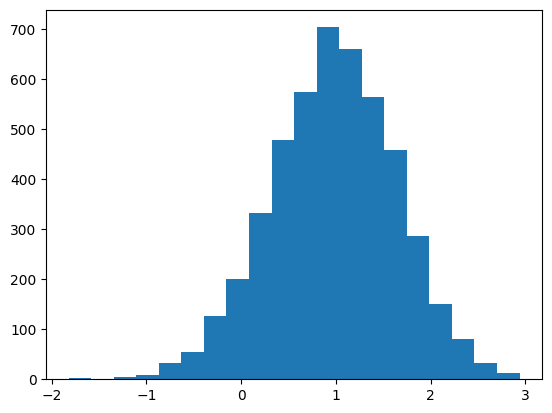

1.3082178562654232 0.005834903519988353


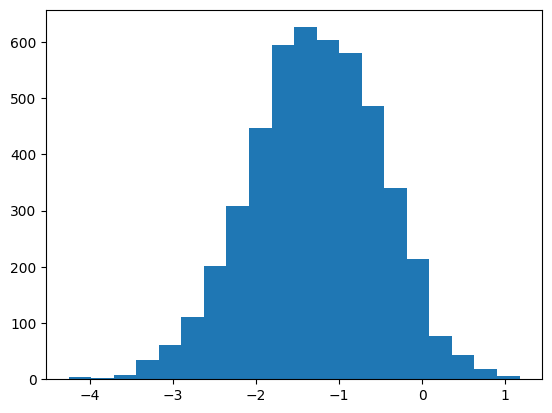

0.8442208024529833 0.003838000767054017


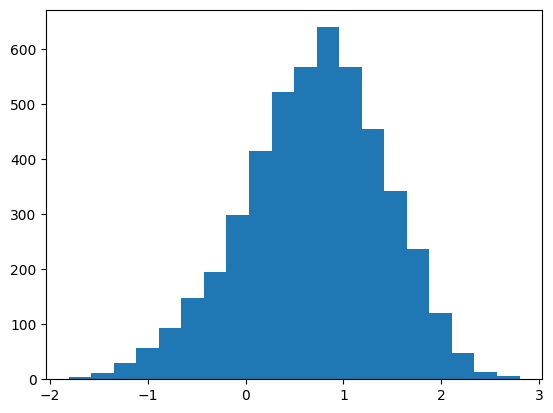

0.6890711491466536 0.0029324782714450215


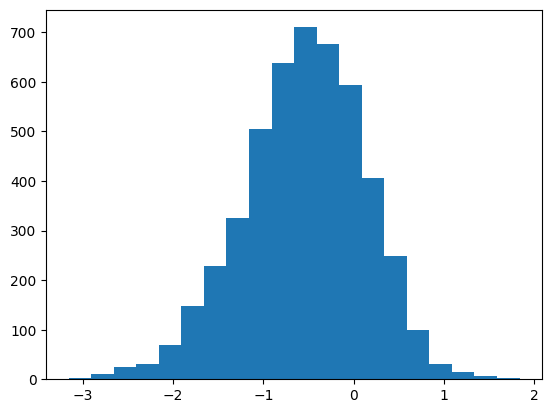

0.8406060683784021 0.0032565106748369244


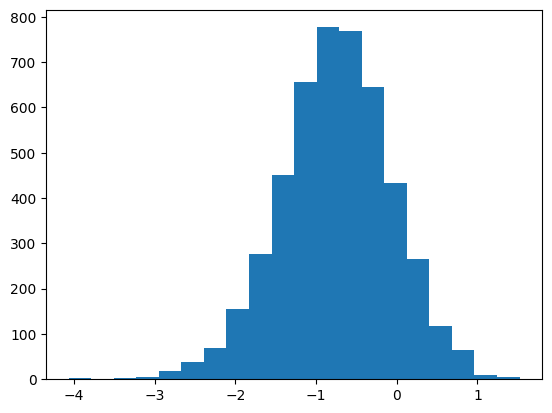

In [145]:
for i in range(50):
    eps, abs_errs = compute_epsilons(pols_estimated[i][0], pols_data[i], np.array(stds[i]))
    print(np.mean(np.abs(eps)), np.mean(np.abs(abs_errs)))
    plt.hist(eps, bins=20)
    plt.show()
    if np.mean(np.abs(eps))>2:
        print(i, eps[np.where(np.abs(eps)>3)], np.where(np.abs(eps)>100))

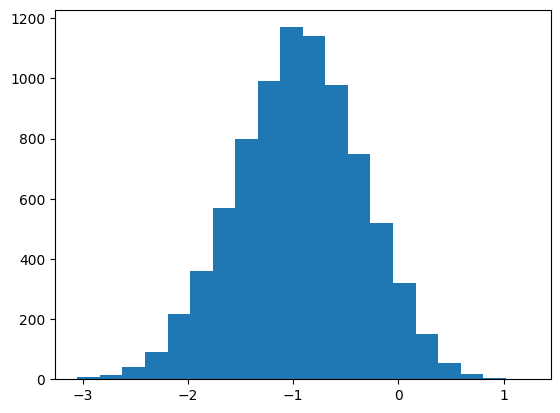

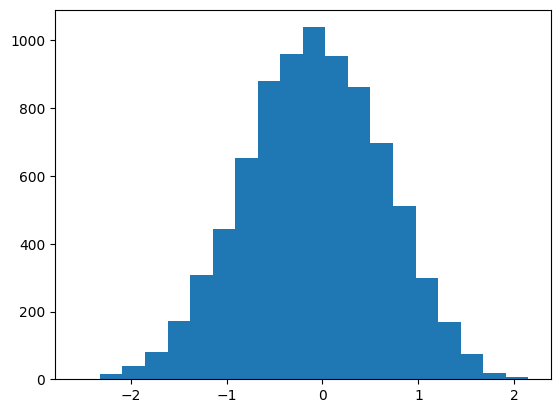

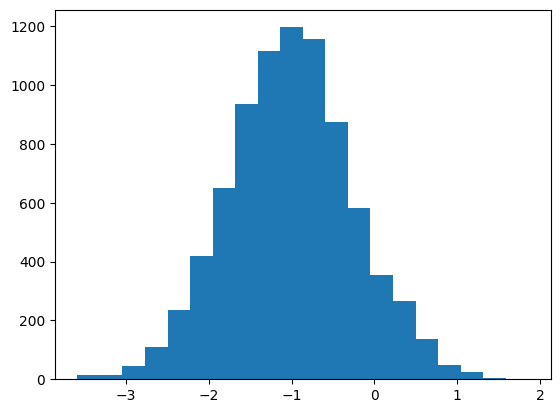

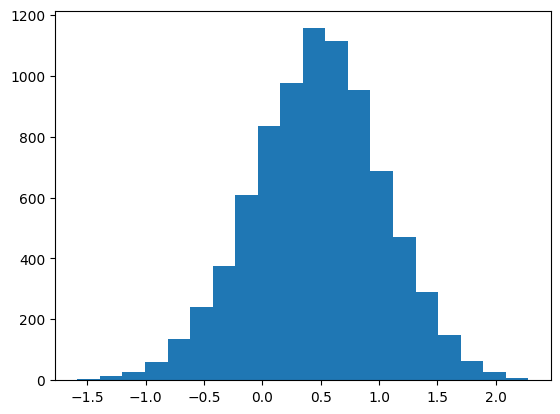

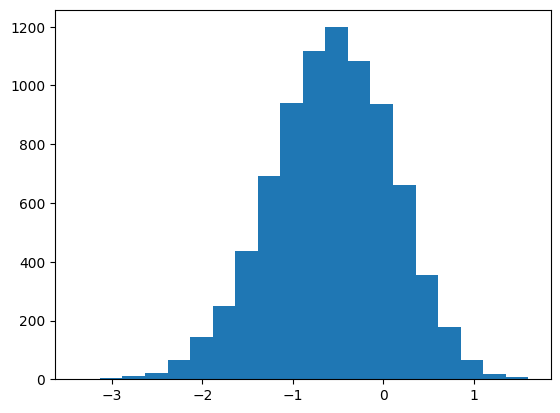

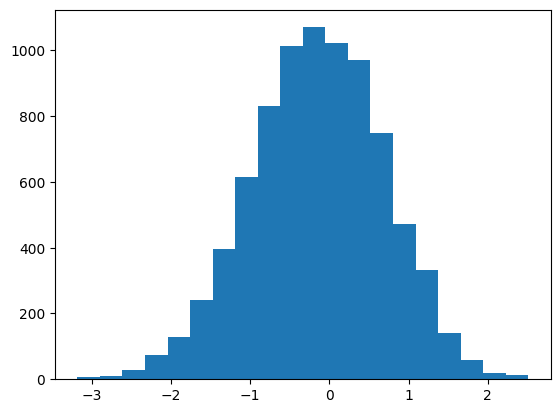

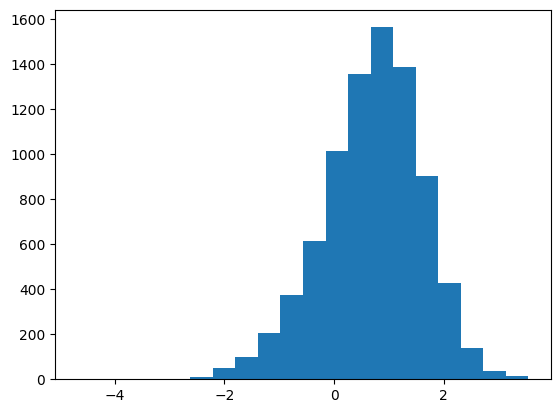

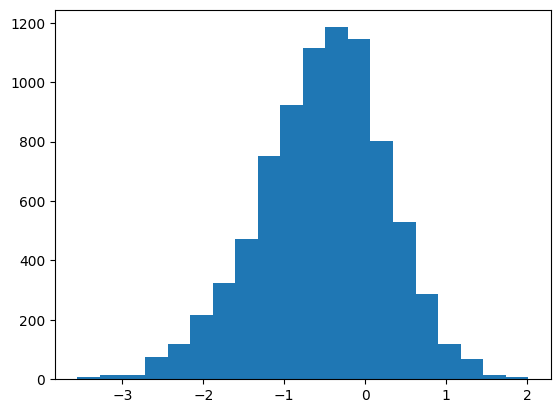

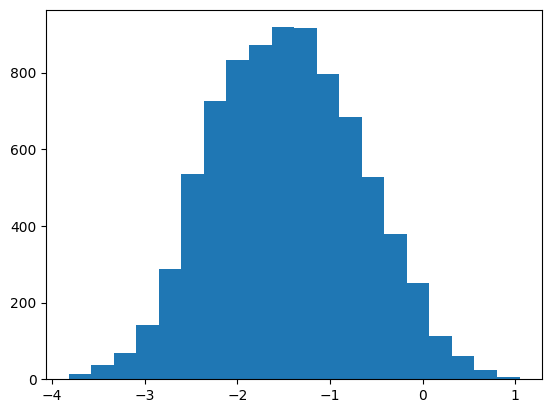

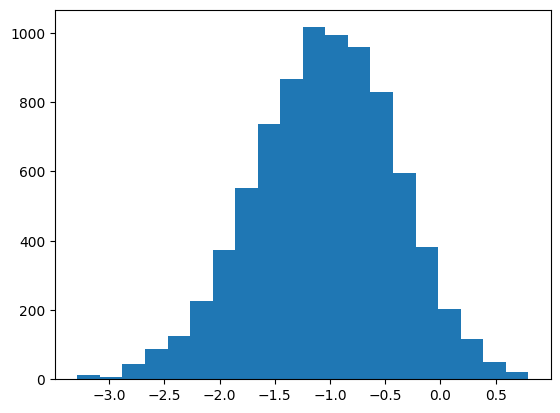

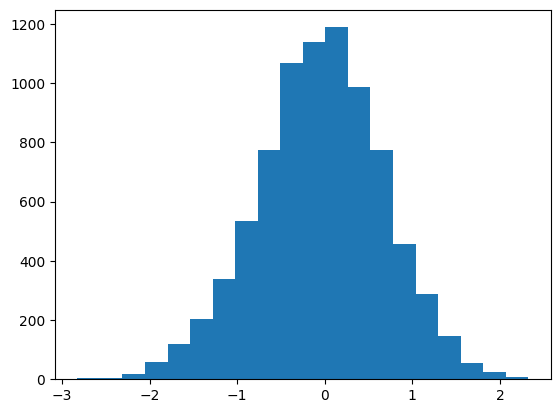

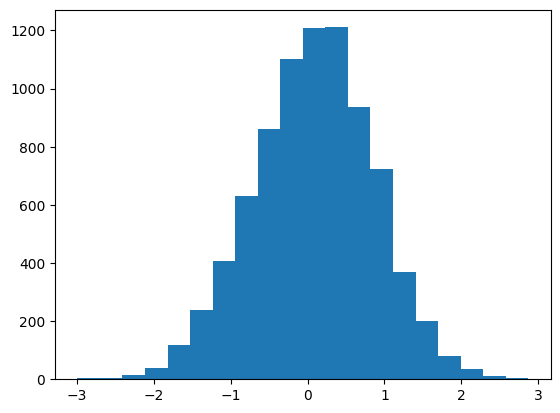

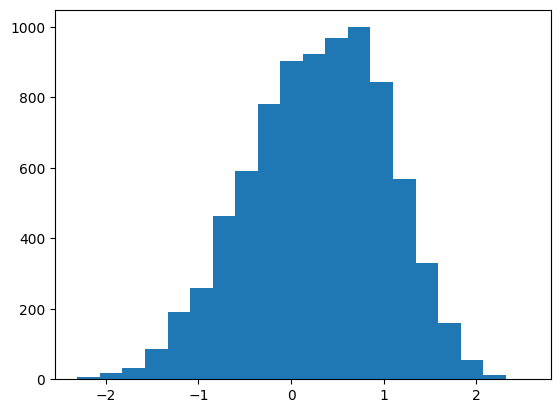

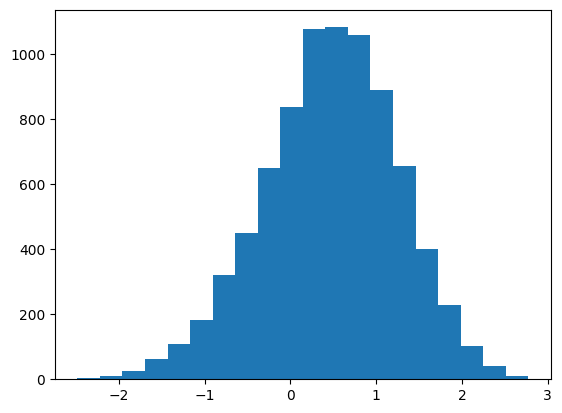

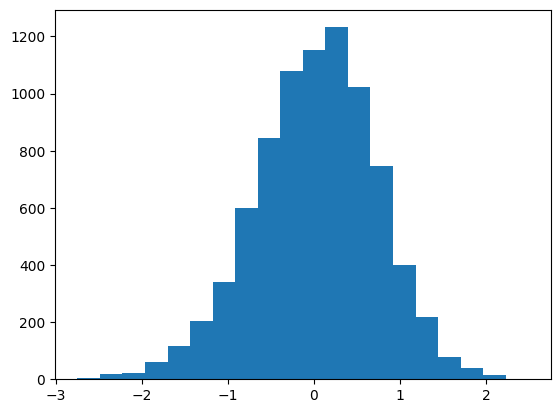

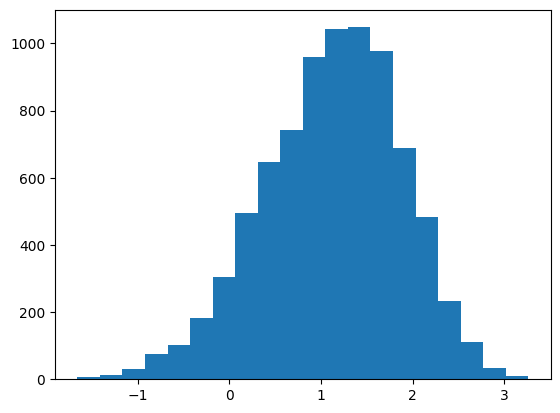

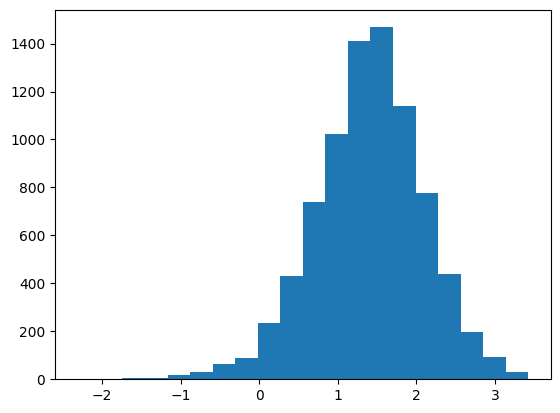

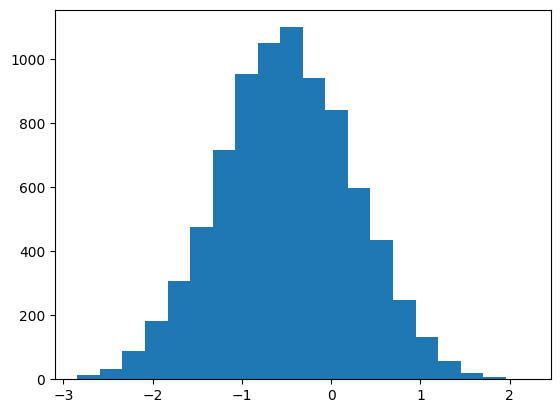

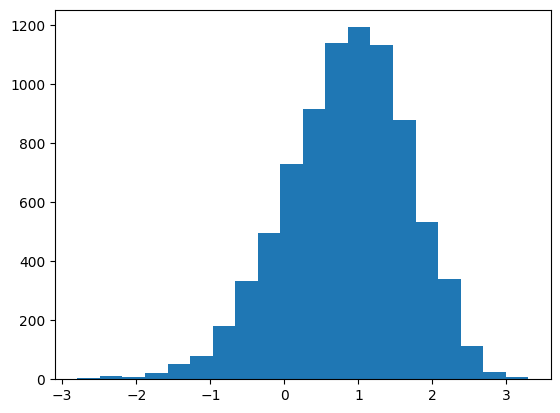

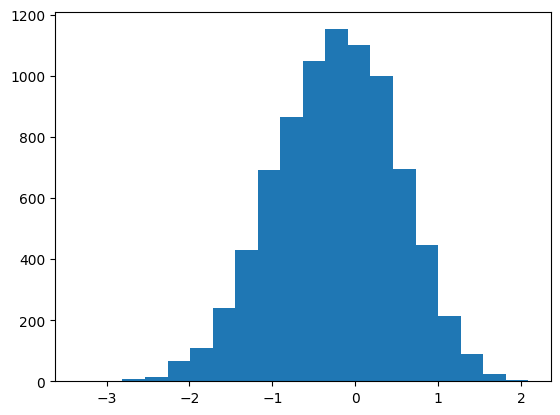

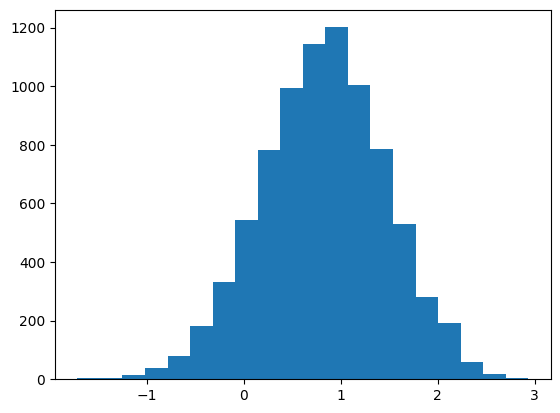

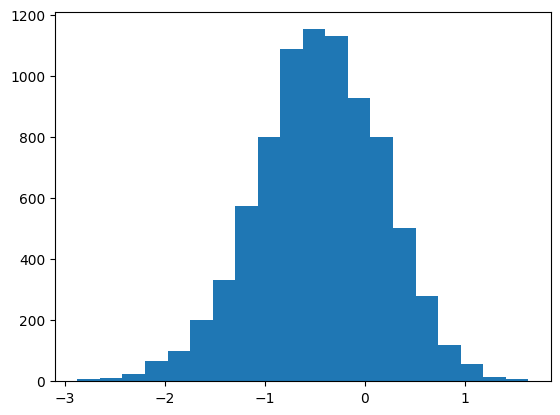

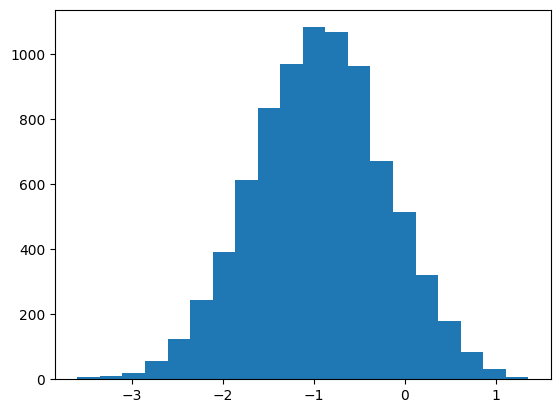

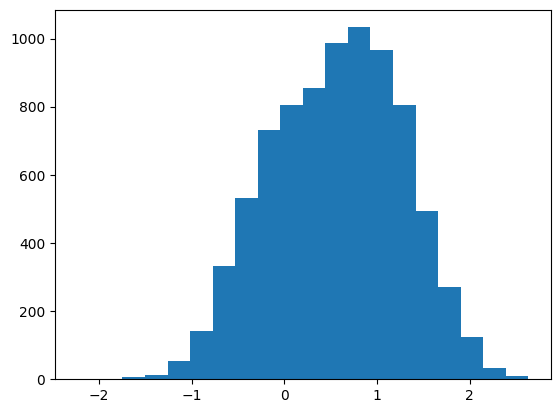

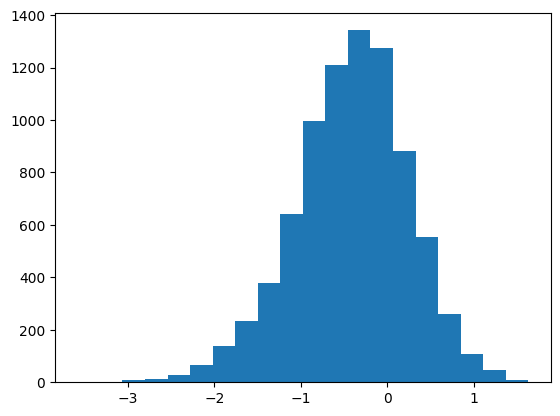

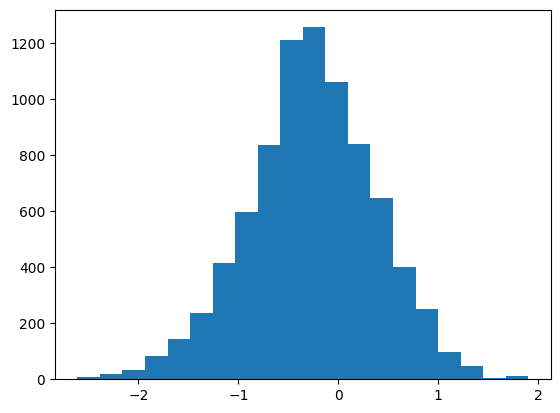

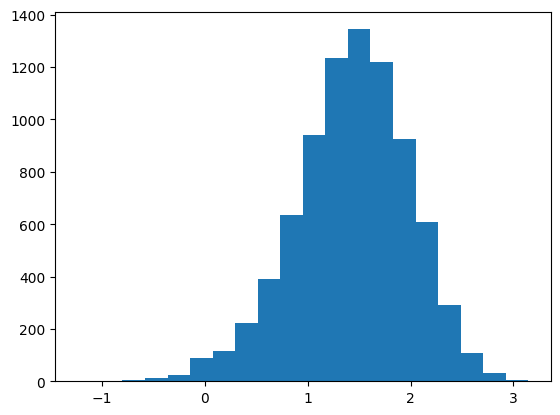

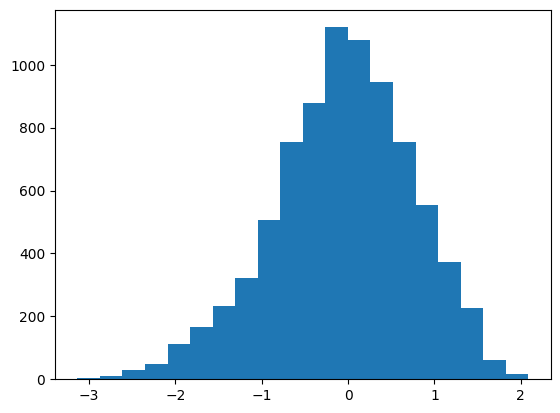

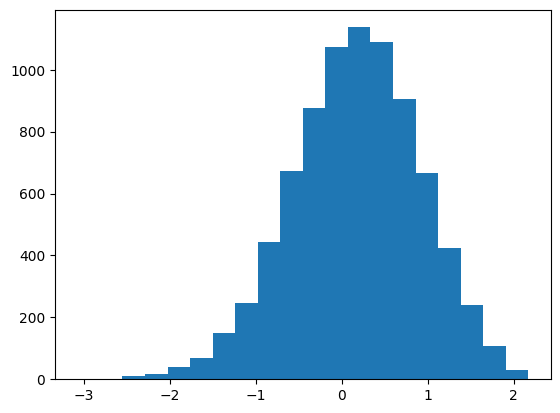

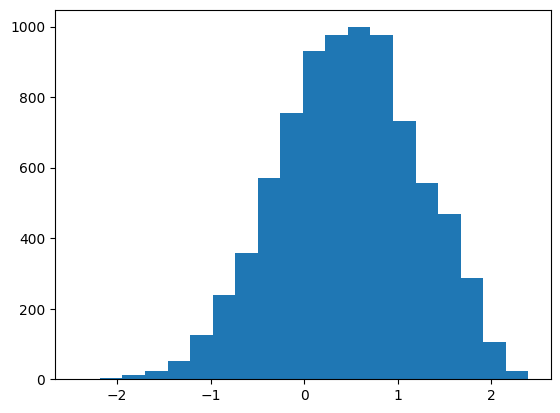

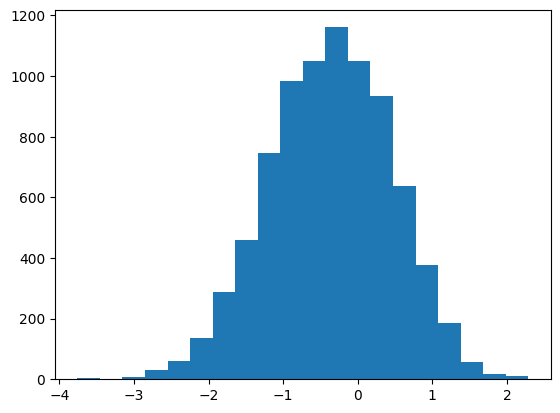

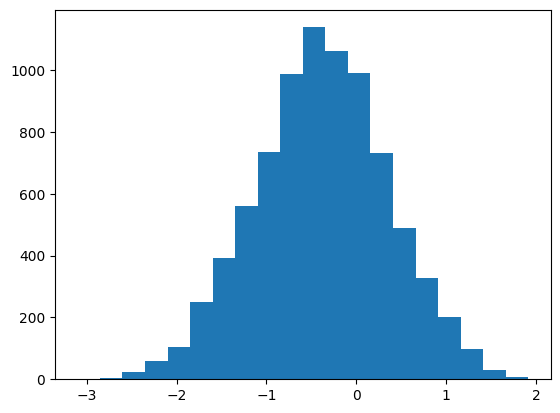

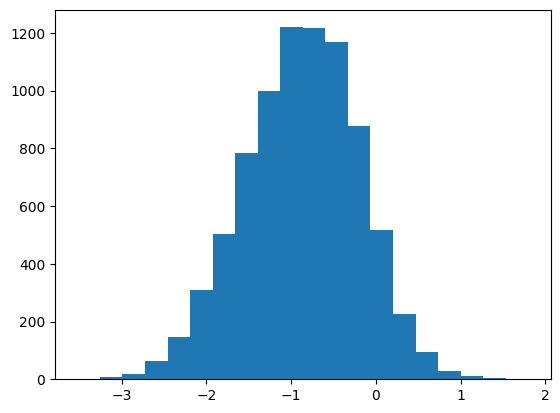

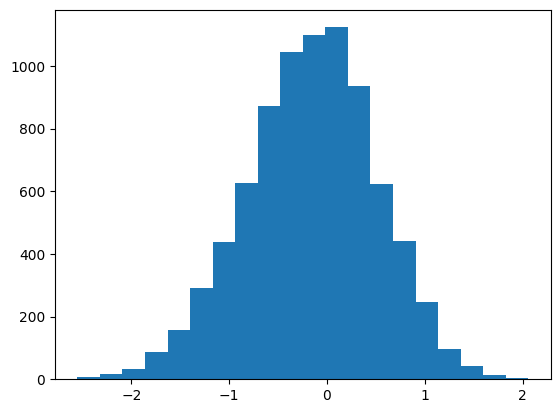

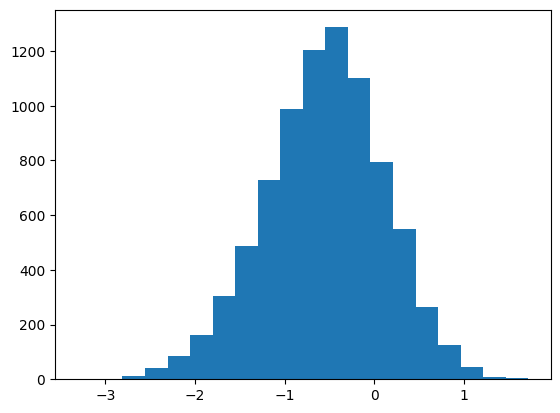

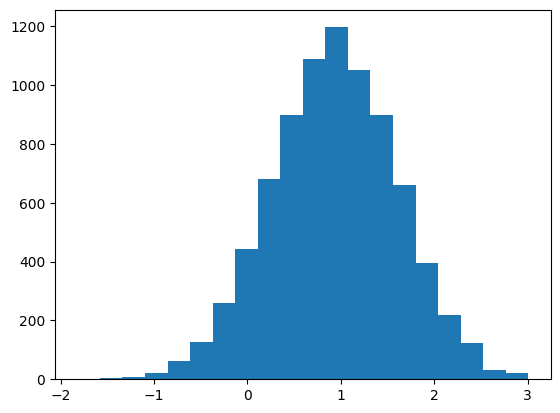

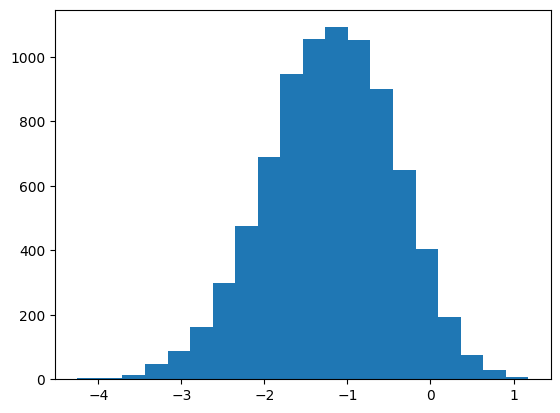

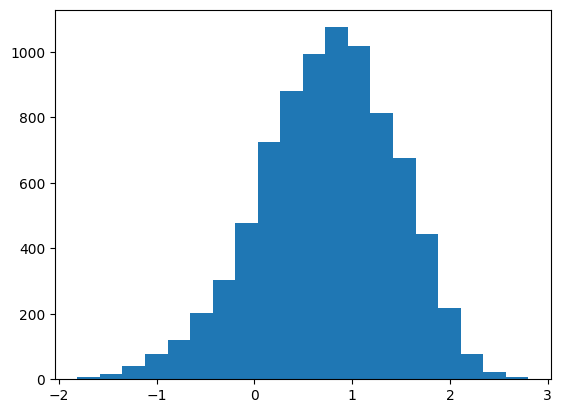

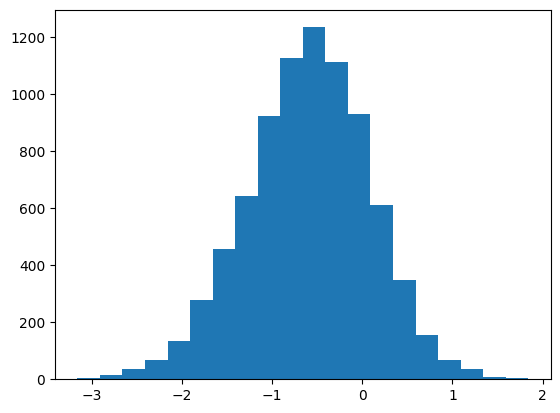

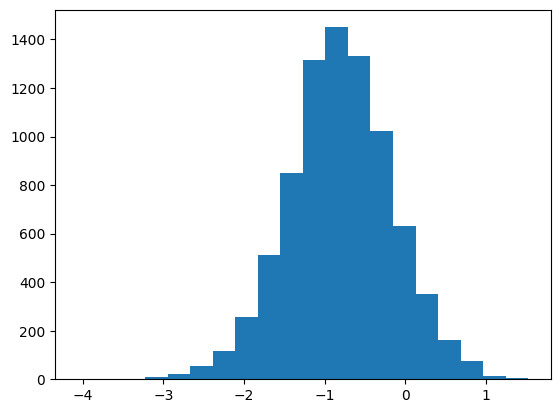

IndexError: list index out of range

In [141]:
for j in js:
    err = (pols_estimated[10+j][0]-pols_data[10+j])/np.array(stds[10+j])
    plt.hist(err,bins=20)
    plt.show()

In [112]:
import pickle
with open('data/loqs_hsca_data_processed.pkl', 'rb') as f:
    percentiles_probs, percentiles_hamming, percentiles_high, pols_data, pols_estimated = pickle.load(f)
f.close()

In [76]:
#np.where(np.array(percentiles_probs)<2.5)

(array([  0, 132, 189]),)

In [191]:
np.where(np.array(percentiles_probs)>95)

(array([  1,  19,  31,  90,  96,  98, 108, 114, 141, 151]),)

In [192]:
np.where(np.array(percentiles_high)>95)

(array([ 63,  97,  98, 108, 110, 118, 136, 141, 160]),)

# Analysis of Sweep of A Error

In [113]:
rounds = 2
ranks = range(1) 
js = range(10)#range(100)
#scha low shots ranks = range(10) js = range(20)
bslen = 13
n_shots_loqs = 10000

percentiles_probs = []
percentiles_hamming = []
percentiles_high = []
pols_data = []
pols_estimated = []

for nm in js:
    with open(f'loqs_data/loqs_dems_damping2_{rounds}_{nm}_{n_shots_loqs}.pkl', 'rb') as f:
        data = pickle.load(f)
    f.close()
    #{'dem_outcome_dist':outcome_distribution, 'dem':dem, 'loqs_samples': count_dict, 'edict':error_rates_dict}

    probs_list = data['dem_outcome_dist']
    dem_dict = data['dem']
    stim_dem_str = dems.format_dem_stim(dem_dict, n_logical=0)
    dem = stim.DetectorErrorModel(stim_dem_str)
    sampler = dem.compile_sampler()

    samples_loqs = data['loqs_samples']
    total_counts = sum(list(samples_loqs.values()))
    probs = {bs:probs_list[to_int(bs[::-1])] for bs in samples_loqs.keys()}
    all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}
    
    p1 = compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p2 = compute_bootstrapped_significance_hamming(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p3 = compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000)

    #percentiles_probs.append(p1)
    #percentiles_hamming.append(p2)
    #percentiles_high.append(p3)
    pols_data.append(compute_all_polarizations(samples_loqs))
    pols_estimated.append(compute_all_polarizations(all_probs))
    print(nm, p1, p2, p3)

0 51.1 99.6 81.39999999999999
1 28.999999999999996 100.0 100.0
2 78.5 100.0 99.9
3 97.0 100.0 100.0
4 30.5 99.9 78.10000000000001
5 100.0 100.0 100.0
6 98.4 100.0 100.0
7 79.60000000000001 100.0 82.89999999999999
8 87.0 100.0 100.0
9 25.2 100.0 100.0


In [106]:
masks, vals, cov = compute_random_polarizations({bs[::-1]:v for bs, v in samples_loqs.items()}, num_polarizations=1000)

In [109]:
vals_pred = compute_specified_polarizations_from_dem(dem, masks)

In [ ]:
for j in js:
    print(max(np.abs(pols_estimated[j]-pols_data[j])))
    plt.hist(np.abs(pols_estimated[j]-pols_data[j]), bins=30)
    plt.show()

In [198]:
rounds = 2
ranks = range(1) 
js = range(10)#range(100)
#scha low shots ranks = range(10) js = range(20)
bslen = 13
n_shots_loqs = 1000 #well getting within 1% 

percentiles_probs = []
percentiles_hamming = []
percentiles_high = []
pols_data = []
pols_estimated = []

for nm in js:
    with open(f'loqs_data/loqs_dems_damping_{rounds}_{nm}_{n_shots_loqs}.pkl', 'rb') as f:
        data = pickle.load(f)
    f.close()

    probs_list = data['dem_outcome_dist']
    dem_dict = data['dem']
    stim_dem_str = dems.format_dem_stim(dem_dict, n_logical=0)
    dem = stim.DetectorErrorModel(stim_dem_str)
    sampler = dem.compile_sampler()

    samples_loqs = data['loqs_samples']
    total_counts = sum(list(samples_loqs.values()))
    probs = {bs:probs_list[to_int(bs[::-1])] for bs in samples_loqs.keys()}
    all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}
    
    p1 = compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p2 = compute_bootstrapped_significance_hamming(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p3 = compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000)

    percentiles_probs.append(p1)
    percentiles_hamming.append(p2)
    percentiles_high.append(p3)
    pols_data.append(compute_all_polarizations(samples_loqs))
    pols_estimated.append(compute_all_polarizations(all_probs))
    print(nm, p1, p2, p3)

KeyboardInterrupt: 

In [49]:
vals, cov = compute_random_polarizations(samples_loqs, num_polarizations=10)

In [34]:
percentiles_high

[99.5, 100.0, 98.7, 96.89999999999999, 100.0, 99.9, 100.0, 100.0, 100.0, 100.0]

In [129]:
pols_data

[array([1.    , 0.8466, 0.94  , ..., 0.5436, 0.5474, 0.5376], shape=(8192,)),
 array([1.    , 0.8424, 0.945 , ..., 0.5614, 0.5672, 0.56  ], shape=(8192,)),
 array([1.    , 0.8518, 0.949 , ..., 0.571 , 0.5718, 0.5708], shape=(8192,)),
 array([1.    , 0.8524, 0.9484, ..., 0.567 , 0.567 , 0.5654], shape=(8192,)),
 array([1.    , 0.8538, 0.9448, ..., 0.5642, 0.5584, 0.5578], shape=(8192,)),
 array([1.    , 0.8468, 0.9414, ..., 0.5718, 0.5684, 0.5672], shape=(8192,)),
 array([1.    , 0.8388, 0.9456, ..., 0.5728, 0.5748, 0.5672], shape=(8192,)),
 array([1.    , 0.8396, 0.941 , ..., 0.5684, 0.5618, 0.5638], shape=(8192,)),
 array([1.    , 0.8362, 0.945 , ..., 0.5648, 0.5732, 0.5566], shape=(8192,)),
 array([1.    , 0.84  , 0.9444, ..., 0.5732, 0.5784, 0.5712], shape=(8192,))]

In [130]:
pols_estimated

[array([1.        , 0.850672  , 0.94761899, ..., 0.53750368, 0.53832264,
        0.5327086 ], shape=(8192,)),
 array([1.        , 0.85066074, 0.94761683, ..., 0.53749911, 0.53831887,
        0.53270528], shape=(8192,)),
 array([1.        , 0.85066074, 0.94761683, ..., 0.53749911, 0.53831887,
        0.53270528], shape=(8192,)),
 array([1.        , 0.85066074, 0.94761683, ..., 0.53749911, 0.53831887,
        0.53270528], shape=(8192,)),
 array([1.        , 0.84801278, 0.94677283, ..., 0.53654312, 0.53783872,
        0.53152115], shape=(8192,)),
 array([1.        , 0.8453729 , 0.94592955, ..., 0.53558878, 0.53735895,
        0.5303396 ], shape=(8192,)),
 array([1.        , 0.84274107, 0.94508696, ..., 0.5346361 , 0.53687954,
        0.52916063], shape=(8192,)),
 array([1.        , 0.84011729, 0.94424508, ..., 0.53368506, 0.53640052,
        0.52798423], shape=(8192,)),
 array([1.        , 0.83750152, 0.94340391, ..., 0.53273567, 0.53592186,
        0.5268104 ], shape=(8192,)),
 array([1.

In [155]:
np.max(np.abs(pols_estimated[9]-pols_data[9]))

np.float64(0.0616434244333256)

In [163]:
bins = np.linspace(-4, -0.5, 140)

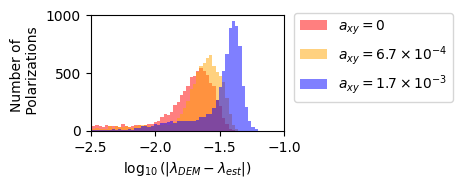

In [187]:
plt.figure(figsize=(2.5,1.5))
colors = ['red', 'orange', 'blue']
labels = [r'''$a_{xy}=0$''', r'''$a_{xy}=6.7\times 10^{-4}$''', r'''$a_{xy}=1.7\times 10^{-3}$''']
for c, j, label in zip(colors, [0, 4, 9], labels):
    plt.hist(np.log10(np.abs(pols_estimated[j][1:] - pols_data[j][1:])), 
             bins=bins, 
             label=label, 
             color=c, 
             alpha=0.5)  # Set alpha for translucency
    #plt.axvline(np.mean(np.log10(np.abs(pols_estimated[j][1:] - pols_data[j][1:]))), 
    #                    color=c)

plt.legend(loc=(1.05, 0.25))
plt.xlim(-2.5, -1)
plt.ylabel('Number of \n Polarizations')
plt.xlabel(r'''$\log_{10}(|\lambda_{DEM}-\lambda_{est}|)$''')
plt.savefig('amplitude_damping_test.pdf')

This is data for 3 rounds, so I haven't computed the full outcome distribution

In [1]:
#results_dict = {'dem_outcome_dist':outcome_distribution, 'dem':dem, 'loqs_samples': count_dict, 'edict':error_rates_dict, 'h_fraction':h_fraction}
rounds = 3

p=1
twoQ_depol_rate = 0.005
hfs = np.linspace(0,1,num=10)
idle_z_rate = np.sqrt(0.01)

n_shots_loqs = 10000

percentiles_probs = []
percentiles_hamming = []
percentiles_high = []
pols_data = []
pols_estimated = []

for h_fraction in hfs:
    with open(f'loqs_data/loqs_dems_sweep_zz_{rounds}_{h_fraction}_{n_shots_loqs}.pkl', 'rb') as f:
        data = pickle.load(f)
    f.close()

    probs_list = data['dem_outcome_dist']
    dem_dict = data['dem']
    stim_dem_str = dems.format_dem_stim(dem_dict, n_logical=0)
    dem = stim.DetectorErrorModel(stim_dem_str)
    sampler = dem.compile_sampler()

    samples_loqs = data['loqs_samples']
    total_counts = sum(list(samples_loqs.values()))
    probs = {bs:probs_list[to_int(bs[::-1])] for bs in samples_loqs.keys()}
    all_probs = {bin(i)[2:].zfill(13)[::-1]:p for i,p in enumerate(probs_list)}
    
    p1 = compute_bootstraped_significance(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p2 = compute_bootstrapped_significance_hamming(sampler, samples_loqs, total_counts, num_bootstraps=1000)
    p3 = compute_bootstrapped_significance_main(sampler, samples_loqs, baseline_events, total_counts, num_bootstraps=1000)

    percentiles_probs.append(p1)
    percentiles_hamming.append(p2)
    percentiles_high.append(p3)
    pols_data.append(compute_all_polarizations(samples_loqs))
    pols_estimated.append(compute_all_polarizations(all_probs))
    print(nm, p1, p2, p3)

    

NameError: name 'np' is not defined

In [85]:
from loqs_dems_helpers import compute_outcome_distribution_from_dem

In [ ]:
compute_outcome_distribution_from_dem(result['dem_outcome_dist']) #this crashes the notebook. Maybe I can try a tensor network approach